World Bank Dataset

1. Data Gathering

In [79]:
import pandas as pd

df = pd.read_csv("c538bed6-24d9-4d25-a075-11dc22bfe385_Data.csv")
df.head()

,Country Name,Country Code,Series Name,Series Code,2021 [YR2021]
0,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,356.496214115892
1,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,60.417
2,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,5.13320340824963
3,Afghanistan,AFG,Population growth (annual %),SP.POP.GROW,2.35609779179185
4,Afghanistan,AFG,"School enrollment, secondary (% gross)",SE.SEC.ENRR,..


In [80]:
df = df.dropna()

2. Make the dataset suitable for exploration and Modeling by pivoting from "Long Format" to "Wide Format"

a) Keep only needed columns

In [81]:
df = df[["Country Name", "Series Name", "2021 [YR2021]"]]

b) Pivot to Wide Format
3. Cleaning
c) replace .. with NaN
d) convert all numeric columns to numbers (skip country name)
e) Drop Rows with missing values • After this, every row will have complete data for all 6 indicators. • The dataset is now fully numeric and clean.

In [82]:
def clean_world_bank_data(df):
    """
    Cleans a long-format World Bank CSV dataset for modeling.

    Args:
        df (pd.DataFrame): Raw dataset in long format.

    Returns:
        pd.DataFrame: Cleaned wide-format numeric dataset ready for ML.
    """
    df = df[["Country Name", "Series Name", "2021 [YR2021]"]]
    df_wide = df.pivot(index="Country Name", columns="Series Name", values="2021 [YR2021]")
    if 'Country Name' not in df_wide.columns:
        df_wide = df_wide.reset_index()
    df_wide.replace("..", pd.NA, inplace=True)
    for col in df_wide.columns[1:]:
        df_wide[col] = pd.to_numeric(df_wide[col])
    df_wide = df_wide.dropna()
    return df_wide

3. Exploration

info()

describe()

In [83]:
df_wide.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Data columns (total 9 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   level_0                                  131 non-null    int64  
 1   index                                    131 non-null    int64  
 2   Country Name                             131 non-null    object 
 3   Current health expenditure (% of GDP)    131 non-null    float64
 4   GDP per capita (current US$)             131 non-null    float64
 5   Inflation, consumer prices (annual %)    131 non-null    float64
 6   Life expectancy at birth, total (years)  131 non-null    float64
 7   Population growth (annual %)             131 non-null    float64
 8   School enrollment, secondary (% gross)   131 non-null    float64
dtypes: float64(6), int64(2), object(1)
memory usage: 9.3+ KB


In [84]:
df_wide.describe()

Series Name,level_0,index,Current health expenditure (% of GDP),GDP per capita (current US$),"Inflation, consumer prices (annual %)","Life expectancy at birth, total (years)",Population growth (annual %),"School enrollment, secondary (% gross)"
count,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000,131.000000
mean,65.000000,106.351145,7.311557,19829.868063,6.224685,72.714473,0.600734,90.847856
std,37.960506,62.079716,2.903688,25074.321161,14.902598,7.072294,1.599670,24.924490
min,0.000000,1.000000,2.147487,483.469463,-0.772844,53.136000,-10.927442,23.154177
25%,32.500000,52.500000,5.059215,3745.064919,2.108407,68.474000,-0.011794,80.787984
50%,65.000000,104.000000,7.086919,7807.887946,3.466926,72.780488,0.626850,94.589928
75%,97.500000,159.500000,9.468875,28572.003061,5.593083,77.828000,1.529453,105.156851
max,130.000000,213.000000,17.352077,134965.815442,154.756096,84.445610,3.444239,143.361343


4. Modeling

a) Define Features (X) and Target (y)

In [85]:
# Features
X = df_wide[[
    "Life expectancy at birth, total (years)",
    "Inflation, consumer prices (annual %)",
    "Population growth (annual %)",
    "School enrollment, secondary (% gross)",
    "Current health expenditure (% of GDP)"
]]

# Target
y = df_wide["GDP per capita (current US$)"]

b) Split, train, Predict, Evaluate

In [86]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

# Feature importance
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})
print(coefficients)

R²: 0.39180302374975395
MAE: 13169.51143416381
                                   Feature  Coefficient
0  Life expectancy at birth, total (years)  2456.368989
1    Inflation, consumer prices (annual %)  -196.141602
2             Population growth (annual %)  3305.724064
3   School enrollment, secondary (% gross)    12.052210
4    Current health expenditure (% of GDP)   932.738478


	•	Interpret them:
	•	Positive coefficients → higher values increase GDP per capita
	•	Negative coefficients → higher values decrease GDP per capita
	•	This gives a clear story for your blog post: which factors matter most.

5. Visualization

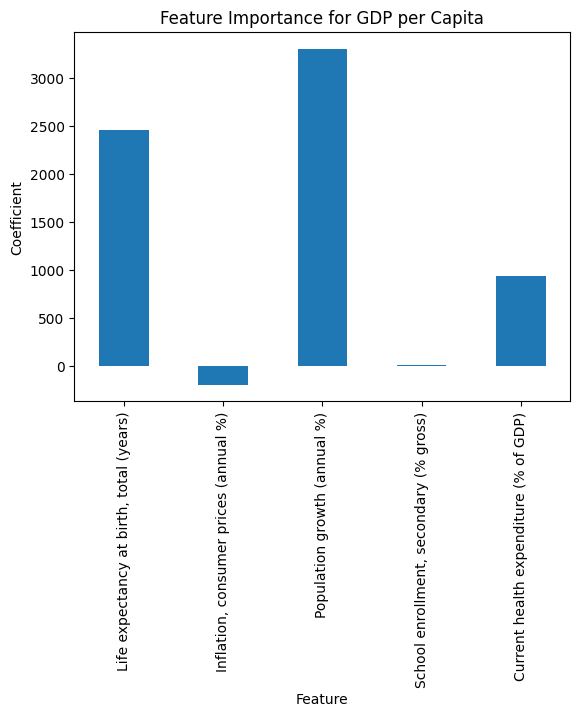

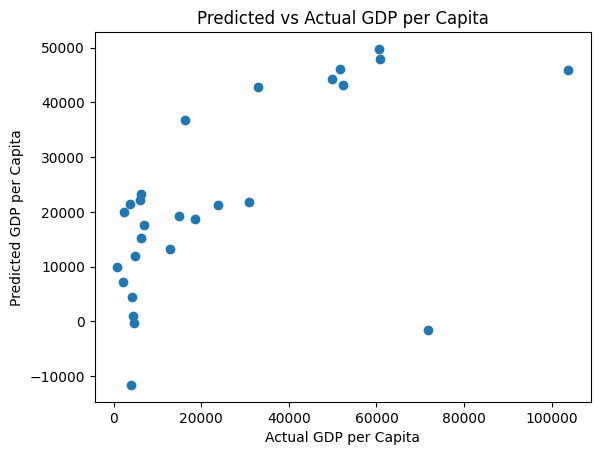

In [87]:
import matplotlib.pyplot as plt

# Feature importance bar chart
coefficients.plot(kind="bar", x="Feature", y="Coefficient", legend=False)
plt.title("Feature Importance for GDP per Capita")
plt.ylabel("Coefficient")
plt.show()

# Predicted vs actual scatter plot
plt.scatter(y_test, y_pred)
plt.xlabel("Actual GDP per Capita")
plt.ylabel("Predicted GDP per Capita")
plt.title("Predicted vs Actual GDP per Capita")
plt.show()

Ah, this is a key part of interpreting your model! The Predicted vs Actual GDP per Capita scatter plot is all about how well your model matches reality. Let me break it down clearly.

⸻

1️⃣ What the plot shows
	•	X-axis: Actual GDP per capita (the true values from your dataset)
	•	Y-axis: Predicted GDP per capita (what your model predicts based on the other features)

Each point represents one country.
	•	If a point lies exactly on the diagonal line (where predicted = actual), your model predicted that country perfectly.
	•	Points above the diagonal mean the model overestimated GDP per capita.
	•	Points below the diagonal mean the model underestimated GDP per capita.

⸻

2️⃣ How to interpret it
	1.	Closeness to the diagonal line:
	•	The closer most points are to the line, the better your model predicts GDP per capita.
	•	Scatter far from the line indicates errors — your model struggles for those countries.
	2.	Patterns in errors:
	•	If high-GDP countries are mostly underpredicted, maybe the model underestimates wealthier countries.
	•	If low-GDP countries are overpredicted, the model may be biased toward the global average.
	3.	Overall accuracy insight:
	•	The plot complements R² and MAE.
	•	R² tells you how much variation is explained, but the scatter plot shows where predictions succeed or fail.

⸻

3️⃣ Real-world takeaway

Looking at your model’s predicted vs actual plot can help you answer questions like:
	•	Are there countries whose GDP per capita is much higher or lower than predicted? Why might that be?
(e.g., resource-rich countries, war-torn economies, or very small countries like Luxembourg or Andorra)
	•	Are the features you chose (life expectancy, health expenditure, education, etc.) enough to explain extreme GDP differences?
	•	Could you improve the model by adding more indicators?

⸻

💡 Example:

If you see most points clustered near the line but a few rich countries are above the line:

“Our model captures general trends well, but it underestimates extremely high-GDP countries. This suggests that other factors, like natural resources or financial hubs, may influence GDP per capita beyond the features used.”

⸻

If you want, I can draw an annotated version of your scatter plot showing exactly what over- and under-prediction looks like and how to explain it in your blog — it makes the insight very clear for readers.

Do you want me to do that?